In [23]:
import pandas as pd


pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import config
from data_utils import FeatureEngineer

In [24]:
data = (pd.read_parquet(config.TIDY_DATA_PATH))
data = data.reset_index(drop=True)


In [25]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float64)

    return df

In [26]:
data = numpy_dtypes(data)

In [27]:
data.dtypes.head()

name        string[python]
position    string[python]
xP                 float64
assists            float64
bonus              float64
dtype: object

In [28]:
data.columns = data.columns.str.lower()

In [29]:
data.drop(columns=["understat", "date"], inplace=True)

In [30]:
data.head()

,name,position,xp,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,code,season,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_xp,opp_xp,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff
0,Andy Lonergan,GK,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-22T14:00:00Z,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,False,0.0,32.0,11948.0,2223.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.0,0.0,0.433712,0.368137,0.433712,0.368137,0.065575,-0.065575,8.818182,9.437500,3.0,5.0,0.065575,-0.619318
1,Andy Lonergan,GK,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-27T18:45:00Z,0.0,15.0,0.0,0.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0,17.0,18.0,1.0,4.0,True,0.0,33.0,11948.0,2223.0,1.0,4.0,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.1780,2.7298,1.0,4.0,0.777008,2.863680,0.777008,2.863680,-2.086672,2.086672,11.363636,9.000000,6.0,9.0,-2.086672,2.363636
2,Andy Lonergan,GK,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01T19:00:00Z,0.0,10.0,0.0,0.0,0.0,0.0,0.0,84.0,0.0,0.0,0.0,19.0,25.0,6.0,4.0,False,0.0,34.0,11948.0,2223.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.3268,1.4183,2.0,2.0,3.286480,3.324860,2.525310,2.563690,-0.038380,0.038380,8.692308,7.523810,9.0,5.0,-0.038380,1.168498
3,Andy Lonergan,GK,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-08T16:30:00Z,0.0,5.0,0.0,0.0,0.0,0.0,0.0,111.0,0.0,0.0,0.0,11.0,32.0,21.0,4.0,False,0.0,35.0,11948.0,2223.0,5.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.2187,1.5493,5.0,1.0,2.942230,3.237170,2.942230,3.237170,-0.294940,0.294940,17.050000,3.058824,10.0,16.0,-0.294940,13.991176
4,Andy Lonergan,GK,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-14T13:00:00Z,0.0,13.0,0.0,0.0,0.0,0.0,0.0,134.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,True,0.0,36.0,11948.0,2223.0,0.0,3.0,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.4578,1.1956,0.0,3.0,1.185970,1.043380,1.185970,1.043380,0.142590,-0.142590,25.400000,17.153846,1.0,9.0,0.142590,8.246154


In [31]:
def exp_per_90(df: pd.DataFrame, x_cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    df = df.reset_index(drop=True)

    minutes = pd.to_numeric(df['minutes'], errors='coerce').replace(0, np.nan)

    for col in x_cols:
        new_col = f"{col}_per_90"

        num_col = pd.to_numeric(df[col], errors='coerce')

        result = num_col / (minutes / 90.0)

        result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
        df[new_col] = result.astype(float)

    return df

In [32]:
data = exp_per_90(df=data,
                  x_cols=[c for c in data.columns if "x" in c and c !="xp" and c != "opp_xp" and c != "team_xp"])

In [33]:
data.head()

,name,position,xp,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,code,season,team_score,opp_score,score_diff,player_id,shots,xg_chain,xg_buildup,key_passes,team_points,opp_points,team_xp,opp_xp,team_goals,opp_goals,team_xg,opp_xg,team_np_xg,opp_np_xg,team_np_xg_difference,opp_np_xg_difference,team_ppda,opp_ppda,team_deep_completions,opp_deep_completions,team_match_np_xg_diff,ppda_diff,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90,ict_index_per_90,xg_chain_per_90,xg_buildup_per_90,team_xg_per_90,opp_xg_per_90,team_np_xg_per_90,opp_np_xg_per_90,team_np_xg_difference_per_90,opp_np_xg_difference_per_90,team_match_np_xg_diff_per_90
0,Andy Lonergan,GK,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-22T14:00:00Z,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,False,0.0,32.0,11948.0,2223.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.0,0.0,0.433712,0.368137,0.433712,0.368137,0.065575,-0.065575,8.818182,9.437500,3.0,5.0,0.065575,-0.619318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Andy Lonergan,GK,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-27T18:45:00Z,0.0,15.0,0.0,0.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0,17.0,18.0,1.0,4.0,True,0.0,33.0,11948.0,2223.0,1.0,4.0,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.1780,2.7298,1.0,4.0,0.777008,2.863680,0.777008,2.863680,-2.086672,2.086672,11.363636,9.000000,6.0,9.0,-2.086672,2.363636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Andy Lonergan,GK,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01T19:00:00Z,0.0,10.0,0.0,0.0,0.0,0.0,0.0,84.0,0.0,0.0,0.0,19.0,25.0,6.0,4.0,False,0.0,34.0,11948.0,2223.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.3268,1.4183,2.0,2.0,3.286480,3.324860,2.525310,2.563690,-0.038380,0.038380,8.692308,7.523810,9.0,5.0,-0.038380,1.168498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Andy Lonergan,GK,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-08T16:30:00Z,0.0,5.0,0.0,0.0,0.0,0.0,0.0,111.0,0.0,0.0,0.0,11.0,32.0,21.0,4.0,False,0.0,35.0,11948.0,2223.0,5.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.2187,1.5493,5.0,1.0,2.942230,3.237170,2.942230,3.237170,-0.294940,0.294940,17.050000,3.058824,10.0,16.0,-0.294940,13.991176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Andy Lonergan,GK,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-14T13:00:00Z,0.0,13.0,0.0,0.0,0.0,0.0,0.0,134.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,True,0.0,36.0,11948.0,2223.0,0.0,3.0,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.4578,1.1956,0.0,3.0,1.185970,1.043380,1.185970,1.043380,0.142590,-0.142590,25.400000,17.153846,1.0,9.0,0.142590,8.246154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
data.columns

Index(['name', 'position', 'xp', 'assists', 'bonus', 'bps', 'clean_sheets',
       'creativity', 'element', 'xa', 'xg_involvements', 'xg', 'xg_conceded',
       'goals_conceded', 'goals_scored', 'ict_index', 'influence',
       'kickoff_time', 'minutes', 'opponent_team', 'own_goals',
       'penalties_missed', 'penalties_saved', 'red_cards', 'saves', 'selected',
       'starts', 'threat', 'total_points', 'transfers_balance', 'transfers_in',
       'transfers_out', 'value', 'was_home', 'yellow_cards', 'gw', 'code',
       'season', 'team_score', 'opp_score', 'score_diff', 'player_id', 'shots',
       'xg_chain', 'xg_buildup', 'key_passes', 'team_points', 'opp_points',
       'team_xp', 'opp_xp', 'team_goals', 'opp_goals', 'team_xg', 'opp_xg',
       'team_np_xg', 'opp_np_xg', 'team_np_xg_difference',
       'opp_np_xg_difference', 'team_ppda', 'opp_ppda',
       'team_deep_completions', 'opp_deep_completions',
       'team_match_np_xg_diff', 'ppda_diff', 'xa_per_90',
       'xg_involvem

In [35]:
data.isna().sum().sum()

np.int64(0)

In [36]:
data["xg_share"] = (data.xg / data.team_xg).replace([np.inf, -np.inf], np.nan).fillna(0)
data["transfers_trend"] = (data.transfers_balance / data.selected).replace([np.inf, -np.inf], np.nan).fillna(0)

In [37]:
data.shape

(105856, 80)

In [38]:
target = ["total_points"]

id_cols = ["name", "element", "kickoff_time", "opponent_team", "gw", "code", "season", "player_id"]

static_cols = ["position", "was_home", "starts"]

fpl_cols = ["bonus", "bps", "ict_index", "influence", "value", "threat"] + [c for c in data.columns if "transfers" in c or "selected" in c]

perf_cols = [c for c in data.columns if c not in target + id_cols + static_cols + fpl_cols]

In [39]:
data.shape[1], len(target + id_cols + static_cols + fpl_cols + perf_cols)

(80, 80)

In [40]:
feature_eng = FeatureEngineer(df=data)
data_lag = feature_eng.features_integration()

In [41]:
data_lag.head()

,transfers_trend,position,name,opponent_team,value,was_home,transfers_out,selected,transfers_in,season,code,kickoff_time,transfers_balance,gw,element,total_points,bonus_ema_8,bps_ema_8,ict_index_ema_8,influence_ema_8,value_ema_8,threat_ema_8,selected_ema_8,transfers_balance_ema_8,transfers_in_ema_8,transfers_out_ema_8,transfers_trend_ema_8,xp_ema_8,assists_ema_8,clean_sheets_ema_8,creativity_ema_8,xa_ema_8,xg_involvements_ema_8,xg_ema_8,xg_conceded_ema_8,goals_conceded_ema_8,goals_scored_ema_8,minutes_ema_8,own_goals_ema_8,penalties_missed_ema_8,penalties_saved_ema_8,red_cards_ema_8,saves_ema_8,yellow_cards_ema_8,team_score_ema_8,opp_score_ema_8,score_diff_ema_8,shots_ema_8,xg_chain_ema_8,xg_buildup_ema_8,key_passes_ema_8,team_points_ema_8,opp_points_ema_8,team_xp_ema_8,opp_xp_ema_8,team_goals_ema_8,opp_goals_ema_8,team_xg_ema_8,opp_xg_ema_8,team_np_xg_ema_8,opp_np_xg_ema_8,team_np_xg_difference_ema_8,opp_np_xg_difference_ema_8,team_ppda_ema_8,opp_ppda_ema_8,team_deep_completions_ema_8,opp_deep_completions_ema_8,team_match_np_xg_diff_ema_8,ppda_diff_ema_8,xa_per_90_ema_8,xg_involvements_per_90_ema_8,xg_per_90_ema_8,xg_conceded_per_90_ema_8,ict_index_per_90_ema_8,xg_chain_per_90_ema_8,xg_buildup_per_90_ema_8,team_xg_per_90_ema_8,opp_xg_per_90_ema_8,team_np_xg_per_90_ema_8,opp_np_xg_per_90_ema_8,team_np_xg_difference_per_90_ema_8,opp_np_xg_difference_per_90_ema_8,team_match_np_xg_diff_per_90_ema_8,xg_share_ema_8,total_points_ema_8,bonus_lagged_1,bps_lagged_1,ict_index_lagged_1,influence_lagged_1,value_lagged_1,threat_lagged_1,selected_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,transfers_trend_lagged_1,xp_lagged_1,assists_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,xa_lagged_1,xg_involvements_lagged_1,xg_lagged_1,xg_conceded_lagged_1,goals_conceded_lagged_1,goals_scored_lagged_1,minutes_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,yellow_cards_lagged_1,team_score_lagged_1,opp_score_lagged_1,score_diff_lagged_1,shots_lagged_1,xg_chain_lagged_1,xg_buildup_lagged_1,key_passes_lagged_1,team_points_lagged_1,opp_points_lagged_1,team_xp_lagged_1,opp_xp_lagged_1,team_goals_lagged_1,opp_goals_lagged_1,team_xg_lagged_1,opp_xg_lagged_1,team_np_xg_lagged_1,opp_np_xg_lagged_1,team_np_xg_difference_lagged_1,opp_np_xg_difference_lagged_1,team_ppda_lagged_1,opp_ppda_lagged_1,team_deep_completions_lagged_1,opp_deep_completions_lagged_1,team_match_np_xg_diff_lagged_1,ppda_diff_lagged_1,xa_per_90_lagged_1,xg_involvements_per_90_lagged_1,xg_per_90_lagged_1,xg_conceded_per_90_lagged_1,ict_index_per_90_lagged_1,xg_chain_per_90_lagged_1,xg_buildup_per_90_lagged_1,team_xg_per_90_lagged_1,opp_xg_per_90_lagged_1,team_np_xg_per_90_lagged_1,opp_np_xg_per_90_lagged_1,team_np_xg_difference_per_90_lagged_1,opp_np_xg_difference_per_90_lagged_1,team_match_np_xg_diff_per_90_lagged_1,xg_share_lagged_1,total_points_lagged_1
0,0.000000,GK,Andy Lonergan,7.0,4.0,False,0.0,0.0,0.0,2223.0,11948.0,2023-04-22T14:00:00Z,0.0,32.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.515152,GK,Andy Lonergan,15.0,4.0,True,1.0,33.0,18.0,2223.0,11948.0,2023-04-27T18:45:00Z,17.0,33.0,760.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,0.0

In [42]:
data_lag.isna().sum().sum()

np.int64(0)

In [43]:
data_lag.shape

(105856, 154)

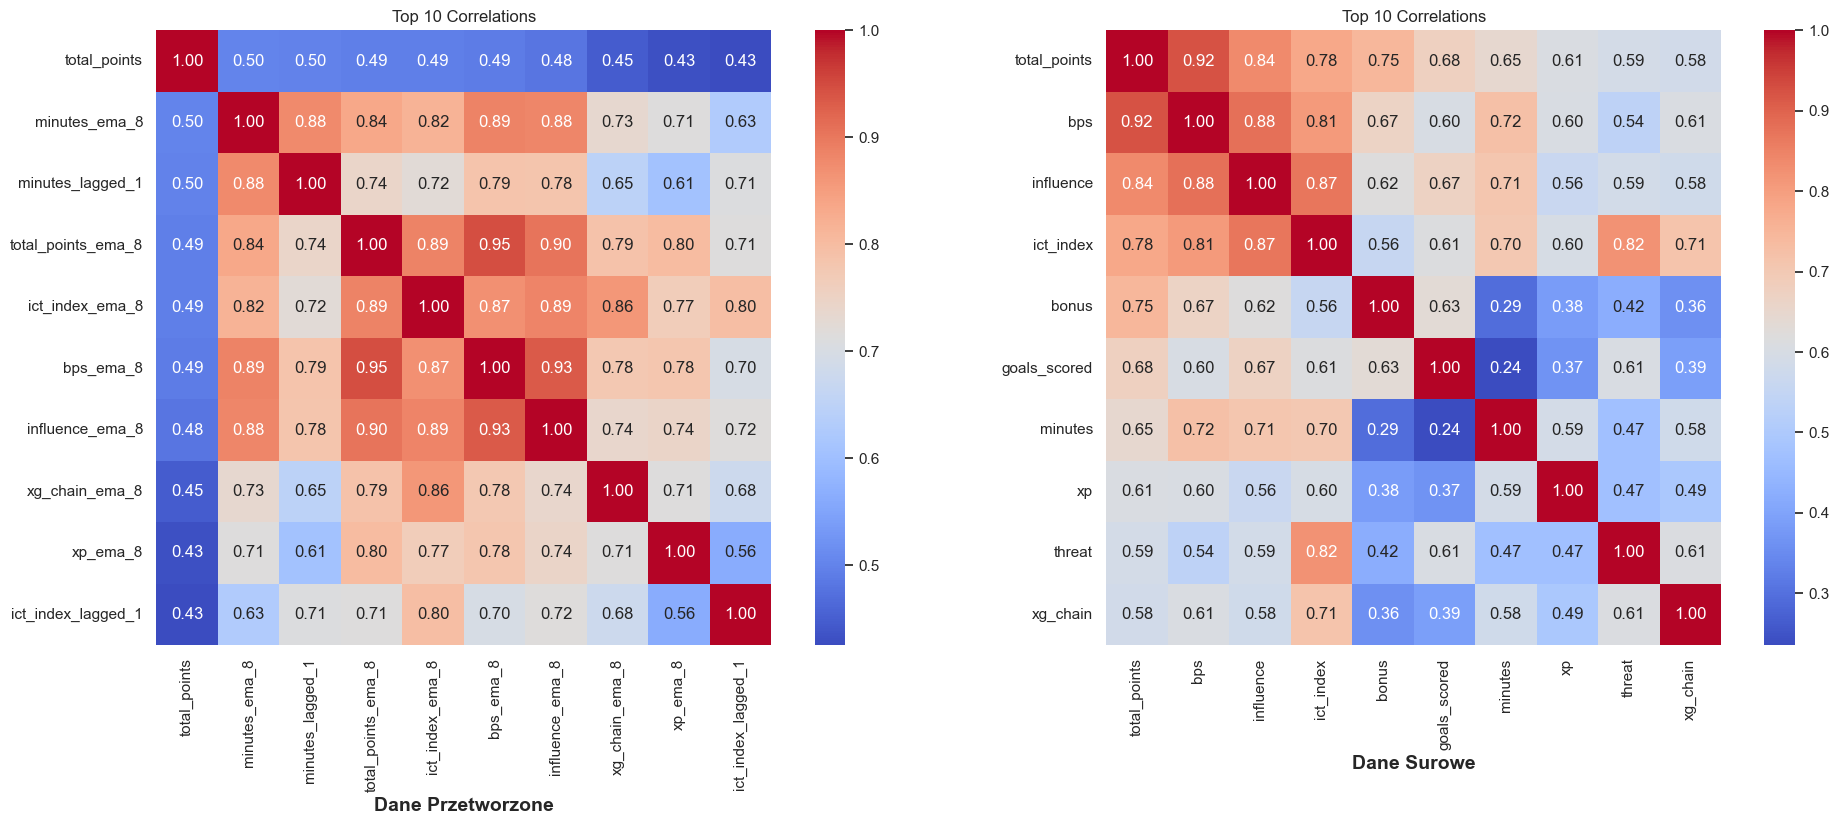

In [44]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["total_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lag, data], ["Dane Przetworzone", "Dane Surowe"])

In [45]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.drop(columns=["total_points"], errors="ignore").select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs


In [46]:
pairs_list = over_corr_pairs(data_lag, threshold=0.9)
pairs = pd.DataFrame(pairs_list)

if not pairs.empty:
    cols_to_drop = pairs[1].unique()
    data_lag.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Usunięto {len(cols_to_drop)} silnie skorelowanych kolumn.")
else:
    print("Nie znaleziono silnie skorelowanych kolumn do usunięcia.")

Usunięto 31 silnie skorelowanych kolumn.


In [47]:
data_lag.shape

(105856, 123)

In [48]:
data_lag.to_parquet(config.FPL_DATA_PATH,
                index=False)